In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks, butter, filtfilt, welch
from scipy.interpolate import interp1d

In [4]:
from pathlib import Path

data_dir = Path.cwd()
ecg = pd.read_csv(data_dir / "103_ekg.csv")
annotation = pd.read_csv(data_dir / "103_annotations_1.csv")

ecg = ecg.rename(columns={"Unnamed: 0": "index"})

display(ecg.head())
display(annotation.head())

,index,MLII,V2,symbol
0,0,-0.375,0.05,NaN
1,1,-0.375,0.05,NaN
2,2,-0.375,0.05,NaN
3,3,-0.375,0.05,NaN
4,4,-0.375,0.05,NaN


,index,annotation_symbol
0,21,+
1,265,N
2,575,N
3,876,N
4,1180,N


In [5]:
print(annotation['annotation_symbol'].value_counts())

annotation_symbol
N    2082
~       6
A       2
+       1
Name: count, dtype: int64


## CREATE NN INTERVELS

time = sample index/ 360 
360 means that 360 sampels were collected

In [7]:
fs= 360
reference_n = annotation[annotation['annotation_symbol'].astype(str).str.strip() == 'N'].copy()
reference_indeces = reference_n['index'].astype(int).to_numpy()
reference_times = reference_indeces / fs

print("number of reference N beats: ", len(reference_indeces))
print("first 10 reference indeces: ", reference_indeces[:10])
print("first 10 reference times: ", reference_times[:10])

number of reference N beats:  2082
first 10 reference indeces:  [ 265  575  876 1180 1482 1795 2127 2444 2744 3044]
first 10 reference times:  [0.73611111 1.59722222 2.43333333 3.27777778 4.11666667 4.98611111
 5.90833333 6.78888889 7.62222222 8.45555556]


In [8]:
nn_intervals_s = np.diff(reference_times)
nn_intervals_ms = nn_intervals_s * 1000  # Convert to milliseconds

print("number of NN intervals: ", len(nn_intervals_ms))
print("first 10 NN intervals (ms): ")
print(nn_intervals_ms[:10])
      

number of NN intervals:  2081
first 10 NN intervals (ms): 
[861.11111111 836.11111111 844.44444444 838.88888889 869.44444444
 922.22222222 880.55555556 833.33333333 833.33333333 841.66666667]


In [9]:
print("minimum NN interval (ms): ", np.min(nn_intervals_ms))
print("maximum NN interval (ms): ", np.max(nn_intervals_ms))
print("mean NN interval (ms): ", np.mean(nn_intervals_ms))
print("median NN interval (ms): ", np.median(nn_intervals_ms))

minimum NN interval (ms):  647.2222222223536
maximum NN interval (ms):  1844.4444444444343
mean NN interval (ms):  867.1178386459501
median NN interval (ms):  869.4444444444435


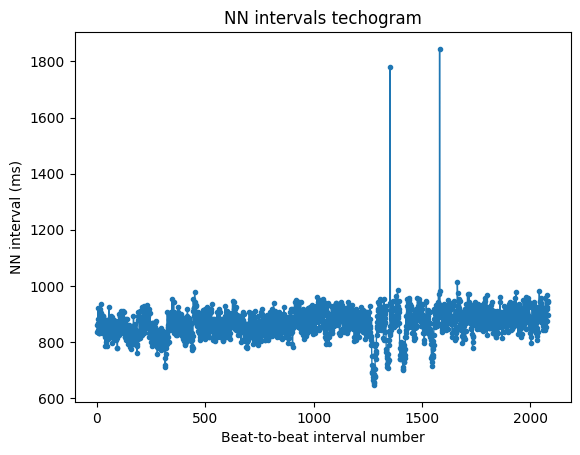

In [10]:
beat_numbers = np.arange(1, len(nn_intervals_ms)+1)

plt.Figure(figsize=(15, 5))
plt.plot(beat_numbers, nn_intervals_ms, marker='o', markersize=3, linewidth=1)

plt.xlabel("Beat-to-beat interval number")
plt.ylabel("NN interval (ms)")
plt.title("NN intervals techogram")
plt.show()

In [11]:
mean_nn_ms = np.mean(nn_intervals_ms)
mean_nn_s = mean_nn_ms / 1000  # Convert to seconds

mean_hr_bpm = 60 / mean_nn_s

sdnn_ms = np.std(nn_intervals_ms, ddof=1)

successive_differences_ms = np.diff(nn_intervals_ms)

rmssd_ms = np.sqrt(np.mean(successive_differences_ms**2))

pnn50_percent = np.sum(np.abs(successive_differences_ms) > 50) / len(successive_differences_ms) * 100

min_nn_ms = np.min(nn_intervals_ms)
max_nn_ms = np.max(nn_intervals_ms)

print("TIME-DOMAIN HRV RESULTS")
print(f"Number of NN intervals: {len(nn_intervals_ms)}")
print(f"Mean NN: {mean_nn_ms:.2f} ms")
print(f"Mean Heart Rate: {mean_hr_bpm:.2f} BPM")
print(f"SDNN: {sdnn_ms:.2f} ms")
print(f"RMSSD: {rmssd_ms:.2f} ms")
print(f"pNN50: {pnn50_percent:.2f} %")
print(f"Minimum NN: {min_nn_ms:.2f} ms")
print(f"Maximum NN: {max_nn_ms:.2f} ms")


TIME-DOMAIN HRV RESULTS
Number of NN intervals: 2081
Mean NN: 867.12 ms
Mean Heart Rate: 69.19 BPM
SDNN: 54.46 ms
RMSSD: 50.62 ms
pNN50: 10.48 %
Minimum NN: 647.22 ms
Maximum NN: 1844.44 ms


## INSTANTANEOUS HEARTRATE

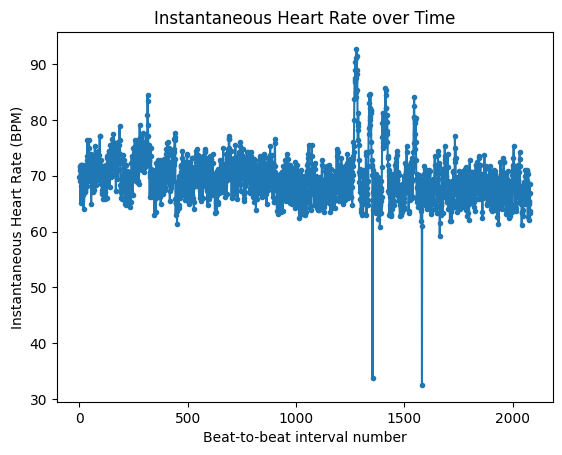

In [12]:
instantaneous_hr_bpm = 60 / nn_intervals_s

plt.Figure(figsize=(15, 5))
plt.plot(beat_numbers, instantaneous_hr_bpm, marker='o', markersize=3)

plt.xlabel("Beat-to-beat interval number")
plt.ylabel("Instantaneous Heart Rate (BPM)")
plt.title("Instantaneous Heart Rate over Time")

plt.show()

In [14]:
nn_hr_table = pd.DataFrame({
    'interval_number': beat_numbers,
    'nn_intervals_ms': nn_intervals_ms,
    'instantaneous_hr_bpm': instantaneous_hr_bpm
})

display(nn_hr_table.head(15))

,interval_number,nn_intervals_ms,instantaneous_hr_bpm
0,1,861.111111,69.677419
1,2,836.111111,71.760797
2,3,844.444444,71.052632
3,4,838.888889,71.523179
4,5,869.444444,69.009585
5,6,922.222222,65.060241
6,7,880.555556,68.138801
7,8,833.333333,72.000000
8,9,833.333333,72.000000
9,10,841.666667,71.287129


## FREQUENCY-DOMAIN HRV ANALYSIS

In [15]:
nn_times = reference_times[1:]  # Times corresponding to NN intervals

valid = np.isfinite(nn_times) & np.isfinite(nn_intervals_ms)

nn_times_valid = nn_times[valid]
nn_values_valid = nn_intervals_ms[valid]

print("NN time range: ", nn_times_valid[0], " to ", nn_times_valid[-1], "seconds")
print("number of valid NN values: ", len(nn_values_valid))

NN time range:  1.5972222222222223  to  1805.2083333333333 seconds
number of valid NN values:  2081


In [16]:
resample_fs = 4.0 

uniform_time = np.arange(nn_times_valid[0], nn_times_valid[-1], 1/resample_fs)

interpolator = interp1d(nn_times_valid, nn_values_valid, kind='linear', bounds_error=False, fill_value='extrapolate')

nn_uniform_ms = interpolator(uniform_time)

print("uniform samples: ", len(nn_uniform_ms))
print("resampling frequency: ", resample_fs, "Hz")

uniform samples:  7215
resampling frequency:  4.0 Hz


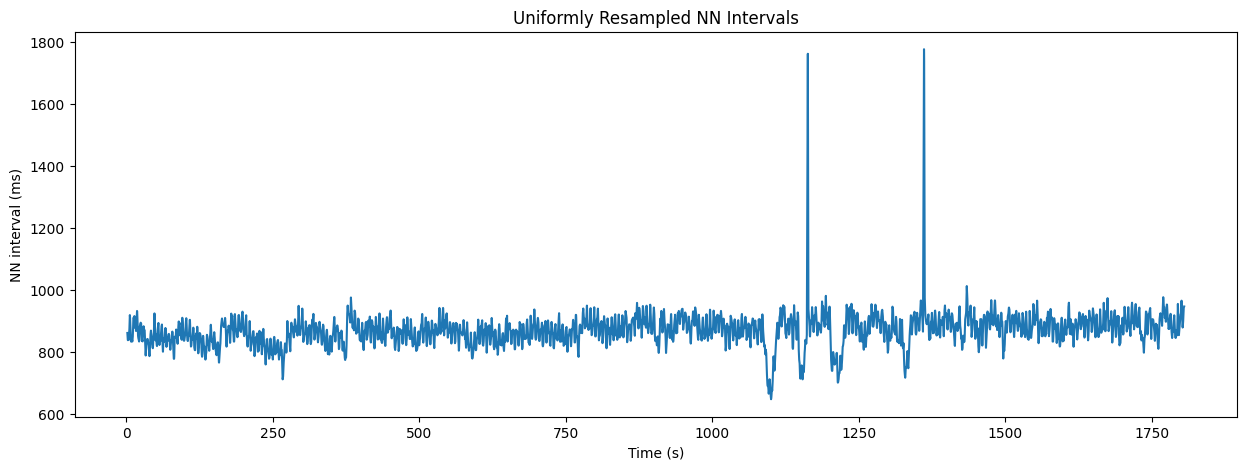

In [17]:
plt.figure(figsize=(15, 5))
plt.plot(uniform_time, nn_uniform_ms)
plt.xlabel("Time (s)")
plt.ylabel("NN interval (ms)")
plt.title("Uniformly Resampled NN Intervals")
plt.show()

## remove mean before PSD estimation

In [18]:
nn_detrended = nn_uniform_ms - np.mean(nn_uniform_ms)
print("mean after detrending: ", np.mean(nn_detrended))

mean after detrending:  5.143088542250239e-14


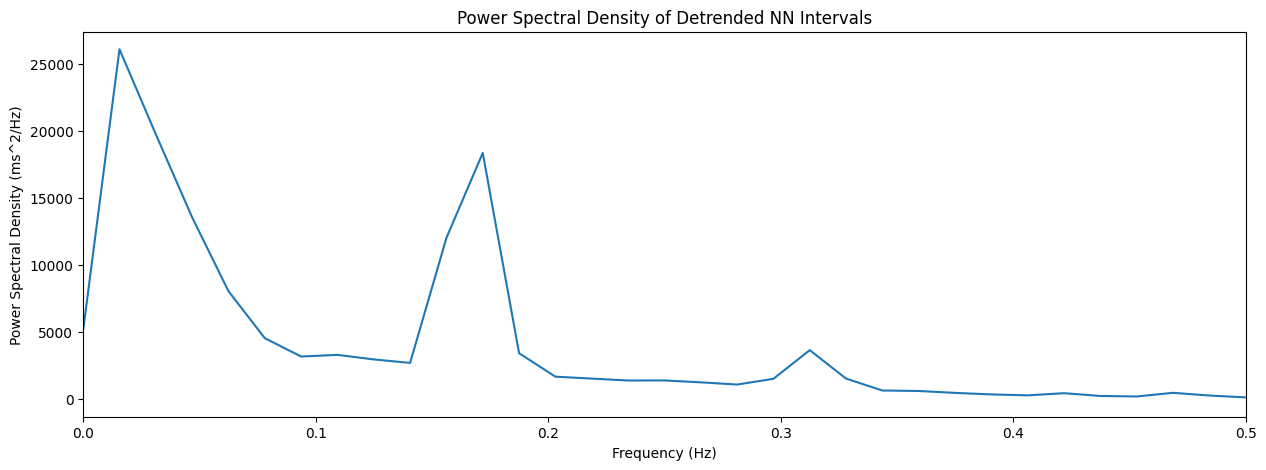

In [19]:
nperseg = min(256, len(nn_detrended))  # Use the smaller of 256 or the length of the detrended signal

frequencies, psd = welch(nn_detrended, fs=resample_fs, nperseg=nperseg, detrend='constant')

plt.figure(figsize=(15, 5))
plt.plot(frequencies, psd)
plt.xlim(0,0.5)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (ms^2/Hz)")
plt.title("Power Spectral Density of Detrended NN Intervals")
plt.show()